 - FE data from study3_50017L_fle
 - Experimental data from 20260708
 - Calibration coefficients from moreCalibration: a, b = 0.0066, 1.3803

In [1]:
import numpy as np
from pathlib import Path
import json
import pandas as pd
import pyvista as pv
import matplotlib.pyplot as plt

from phd_helpers.experiments import (
    get_sensor_loc, parse_tekscan, F2P, build_sensor_mesh, project_sensor, project_sensor_new, project_sensor_complex, force_per_frame
)
from phd_helpers.AbaqusPostprocessing import inp2pv, get_field_path, get_field_df, add_field_to_mesh, get_history_path

In [2]:
fea_path = Path('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy/study3_50017L_fle')
inp_file = list(fea_path.glob('**/*.inp'))[0]
inp_file

PosixPath('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy/study3_50017L_fle/inpFiles/50017L/inp/35T-flexion-00/35T-flexion-00.inp')

In [3]:
def get_step_ids(inp_file):
    history_files = list(inp_file.parent.glob('resultCSVs/history*.csv'))
    step_ids = np.sort(np.unique([int(x.with_suffix('').name.replace('history_step-', '')) for x in history_files]))
    return step_ids

def fea_mets_from_mesh(mesh):
    return {
        'CA': mesh.field_data['CA'][0],
        'P_max': mesh.field_data['P_max'][0],
        'P_avg': mesh.field_data['P_avg'][0],
        'loc_Pmax': mesh.field_data['loc_Pmax'],
    }

def find_boundary_cells(a):
    """
    input: NxM array of cells
    Returns: NxM (1, 0) array of non-zero cells that border a zero"""
    a = np.asarray(a)
    m = a > 0
    out = np.zeros(a.shape, dtype=bool)

    out[1:, :]  |= m[1:, :]  & (a[:-1, :] == 0)
    out[:-1, :] |= m[:-1, :] & (a[1:, :] == 0)
    out[:, 1:]  |= m[:, 1:]  & (a[:, :-1] == 0)
    out[:, :-1] |= m[:, :-1] & (a[:, 1:] == 0)

    return out

def compute_img_metrics(img, sensel_area=1.6129):

    CA = len(img[img>0]) * sensel_area
    # CA error - between 25% and 125% of the area of the boundary cells 
    # - plenty of cases that could exceed these limits but still reasonable limits I think...
    # - Given the nature of the contacting surfaces, it would be impossible for every boundary cell to be an edge case 
    # - so error bars based on those would give unreasonably wide range
    CA_e_low = find_boundary_cells(img).sum() * sensel_area * 0.75 # lower bound error bar for CA
    CA_e_high = find_boundary_cells(img).sum() * sensel_area * 0.25 # upper bound error bar for CA
    
    P_max = img.max()
    P_avg = img[img>0].mean()
    loc_Pmax = np.array(np.where(img==img.max())).ravel() # idx - (i, j)

    return {
        'CA': CA,
        'CA_e_low': CA_e_low,
        'CA_e_high': CA_e_high,
        'P_max': P_max,
        'P_avg': P_avg,
        'loc_Pmax': loc_Pmax
    }

def compute_CA_overlap(img_fea, img_tek):
    mask_fea = (img_fea > 0)
    mask_tek = (img_tek > 0)
    CA_mean = (mask_fea.sum() + mask_tek.sum()) / 2
    CA_overlap = (mask_fea & mask_tek).sum()

    return 100-(100 * (CA_mean - CA_overlap) / CA_mean)

def compute_Pavg(mesh):
    """Converts CPRESS to cell data and computes area weighted average pressure"""
    tet_surf = mesh.extract_cells_by_type(10).extract_surface(algorithm=None)
    P = tet_surf.point_data_to_cell_data().cell_data['CPRESS'] 
        # CPRESS comes as point data
        # this assigns to each elements CPRESS value, the average of the CPRESS of the 3 points of the element
        # Edge case: elements has point CPRESS = [0, 0, 1.5], element given CPRESS = 0.5, but entire area considered in contact for avg
        # This slightly overestimates area and therefore reduces average pressure
    A = tet_surf.compute_cell_sizes()["Area"]
    mask = P > 0

    return np.sum(P[mask] * A[mask]) / np.sum(A[mask])

# Load tekscan data

In [4]:
tek_paths = list(Path('../../../../Experimental/LabData/contactTesting/20260708/50017L').glob('*.asm'))
tek_paths

[PosixPath('../../../../Experimental/LabData/contactTesting/20260708/50017L/neu20_1.asm'),
 PosixPath('../../../../Experimental/LabData/contactTesting/20260708/50017L/neu150_1.asm'),
 PosixPath('../../../../Experimental/LabData/contactTesting/20260708/50017L/neu40_1.asm'),
 PosixPath('../../../../Experimental/LabData/contactTesting/20260708/50017L/neu10_1.asm'),
 PosixPath('../../../../Experimental/LabData/contactTesting/20260708/50017L/neu30_1.asm'),
 PosixPath('../../../../Experimental/LabData/contactTesting/20260708/50017L/neu70_1.asm'),
 PosixPath('../../../../Experimental/LabData/contactTesting/20260708/50017L/neu100_1.asm'),
 PosixPath('../../../../Experimental/LabData/contactTesting/20260708/50017L/neu50_1.asm')]

In [5]:
a, b = 0.0066, 1.3803
frame_window = 5 # s

header, (_, _, _, _) = parse_tekscan(tek_paths[0])
SPF = float(header['SECONDS_PER_FRAME'])

def avg_frame(frames, start_time, window=5, raw_mask=0):
    n_frames = np.ceil(window / SPF).astype(int)
    start_frame = np.round(start_time / SPF).astype(int)
    end_frame = start_frame + n_frames
    frame = np.mean(frames[start_frame:end_frame+1], axis=0)
    frame[frame <= raw_mask] = 0
    return frame

# new test data
raw_tek = {
    int(path.name.replace('_1.asm', '')[3:]): avg_frame(parse_tekscan(path, 3), start_time=0, window=frame_window) for path in tek_paths
    }
tek_data = {F: a*frame**b for F, frame in raw_tek.items()}

# Load FEA data

In [6]:
param_path = inp_file.parents[4]/ 'params/full_params.json'
with open(param_path, 'r') as f:
    Fs = json.load(f)['inp']['force_steps']

force_steps = get_step_ids(inp_file)[1:]
bone = 'tpm'

frame = -1 # final frame of each step
field_metrics = ["CPRESS", "U"]

csv_dir = inp_file.parent / 'resultCSVs' 


fea_data = {} # {F1: {'tpm':mesh1, 'mc1':mesh1}, ...} - each mesh contains all fea data
for step, F in zip(force_steps, Fs):
    #meshes = meshes_orig.copy()
    meshes = inp2pv(inp_file)
    for bone, mesh in meshes.items():
        instance = f"{bone.upper()}_INST"
        
        # Field data
        for metric in field_metrics:
            field_path = get_field_path(csv_dir, metric, step, frame, instance)
            field_df = get_field_df(field_path)
            add_field_to_mesh(mesh, field_df)

        # History data
        history_data = pd.read_csv(get_history_path(csv_dir, step))
        # A
        CAREA_data = history_data[history_data['historyOutputDescription']=='Total area in contact']
        CA = CAREA_data['value'].iloc[frame]

        mesh.field_data['RF'] = F
        mesh.field_data['CA'] = CA

        #P_avg = np.mean(mesh['CPRESS'][mesh['CPRESS']>0])
        #Summary data
        mesh.field_data['P_max'] = mesh['CPRESS'].max()
        mesh.field_data['P_avg'] = compute_Pavg(mesh)
        mesh.field_data['loc_Pmax'] = np.array(mesh.points[np.argmax(mesh['CPRESS'])])

    fea_data[F] = meshes

In [ ]:
fea_grid_data = {}
for F in tek_data:

    surf = fea_data[F][bone].extract_surface(algorithm=None)
    mesh = surf.extract_cells(surf[f'{bone}_CART_SURF']==1).extract_surface(algorithm=None)

    sensor_loc = get_sensor_loc(fea_data[F]['mc1'], guide_wall_z=13.6, sensor_offset_z=-2, sensor_size=13.97) # skinny guide ledge
    sensor = build_sensor_mesh(sensor_loc, normal=(1, 0, 0), ncells=11, size=13.97)
    
    fea_grid_new = project_sensor_new(
        mesh=mesh,
        sensor=sensor,
        sensor_vals=tek_data[F],
        data_loc="cells",
        downscale_fea=True,
        return_fea_grid=True,
        active_sensel_width=0.635,
        pressure_name="CPRESS",
    )
    
    
    fea_grid_data[F] = fea_grid_new

# Plot results

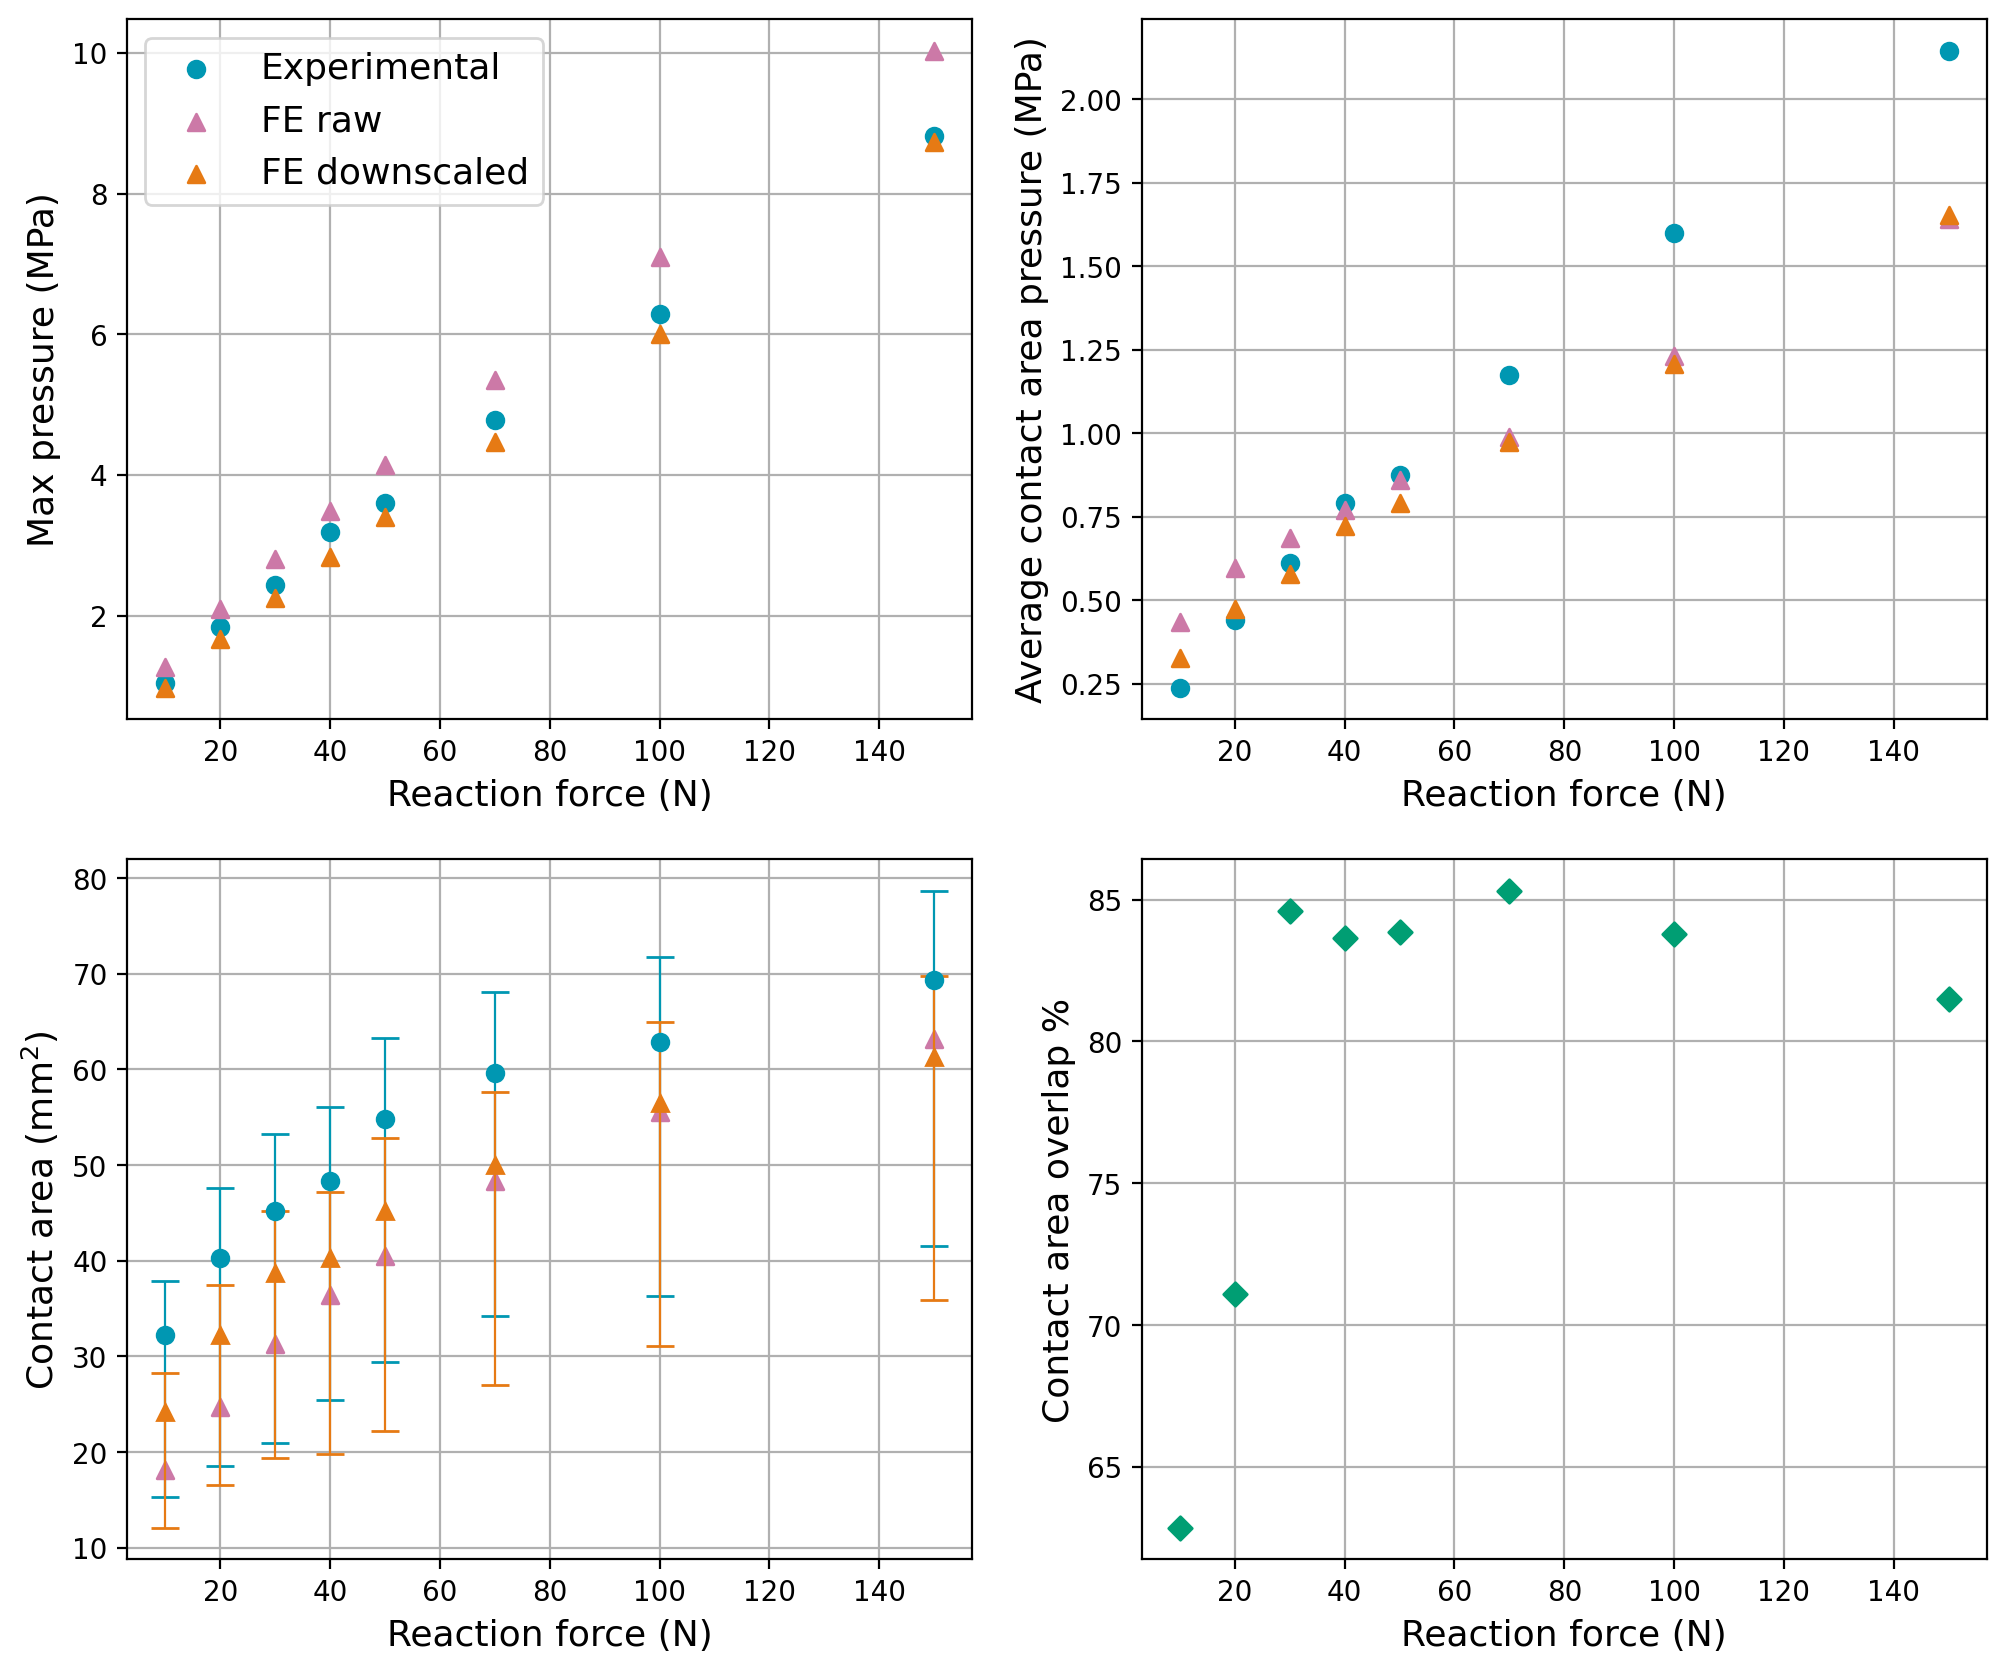

In [8]:
bone = 'tpm'

nrows, ncols = 2, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*5), dpi=200)
ax = ax.flatten()


fs = 13
colors = {
    "tek": "#0097b2",
         #"#009e73"
    "FE downscaled": "#e67a14",
    'FE raw': "#cc79a7"
         #"#cc79a7"
         #"#bfb200"
    }
markers = {
    "tek": "o", 
    "FE downscaled": "^",
    'FE raw': "^"
}

for F in tek_data:
    tek_mets = compute_img_metrics(tek_data[F])
    fea_mets = fea_mets_from_mesh(fea_data[F][bone])

    label_tek = 'Experimental' if F==10 else None
    label_fea = 'FE raw' if F==10 else None
    ax[0].scatter(F, tek_mets['P_max'], c=colors['tek'], marker=markers['tek'], label=label_tek, zorder=2)
    ax[1].scatter(F, tek_mets['P_avg'], c=colors['tek'], marker=markers['tek'], zorder=2)
    #ax[2].scatter(F, tek_mets['CA'], c=colors['tek'], marker=markers['tek'], zorder=2)
    ax[2].errorbar(F, tek_mets['CA'], yerr=[[tek_mets['CA_e_low']], [tek_mets['CA_e_high']]] , c=colors['tek'], marker=markers['tek'], capsize=5, elinewidth=0.8)

    ax[0].scatter(F, fea_mets['P_max'], c=colors['FE raw'], marker=markers['FE raw'], label=label_fea, zorder=2)
    ax[1].scatter(F, fea_mets['P_avg'], c=colors['FE raw'], marker=markers['FE raw'], zorder=2)
    ax[2].scatter(F, fea_mets['CA'], c=colors['FE raw'], marker=markers['FE raw'], zorder=2)

for F in tek_data:
    fea_mets = compute_img_metrics(fea_grid_data[F])
    tek_mets = compute_img_metrics(tek_data[F])

    label_fea = 'FE downscaled' if F==10 else None
    ax[0].scatter(F, fea_mets['P_max'], c=colors['FE downscaled'], marker=markers['FE downscaled'], label=label_fea, zorder=2)
    ax[1].scatter(F, fea_mets['P_avg'], c=colors['FE downscaled'], marker=markers['FE downscaled'], zorder=2)
    #ax[2].scatter(F, fea_mets['CA'], c=colors['FE downscaled'], marker=markers['FE downscaled'], zorder=2)
    ax[2].errorbar(F, fea_mets['CA'], yerr=[[fea_mets['CA_e_low']],[fea_mets['CA_e_high']]],c=colors['FE downscaled'],marker=markers['FE downscaled'],capsize=5,elinewidth=0.8)


    ax[3].scatter(F, compute_CA_overlap(fea_grid_data[F], tek_data[F]), c="#009e73", marker="D", label=label_fea, zorder=2)



ax[0].set_ylabel('Max pressure (MPa)', fontsize=fs)
ax[1].set_ylabel('Average contact area pressure (MPa)', fontsize=fs)
ax[2].set_ylabel('Contact area (mm$^2$)', fontsize=fs)
ax[3].set_ylabel('Contact area overlap %', fontsize=fs)
for ax_i in ax:
    ax_i.set_xlabel('Reaction force (N)', fontsize=fs)
    ax_i.grid()
ax[0].legend(fontsize=fs)
#ax[3].legend(fontsize=fs)
plt.show()

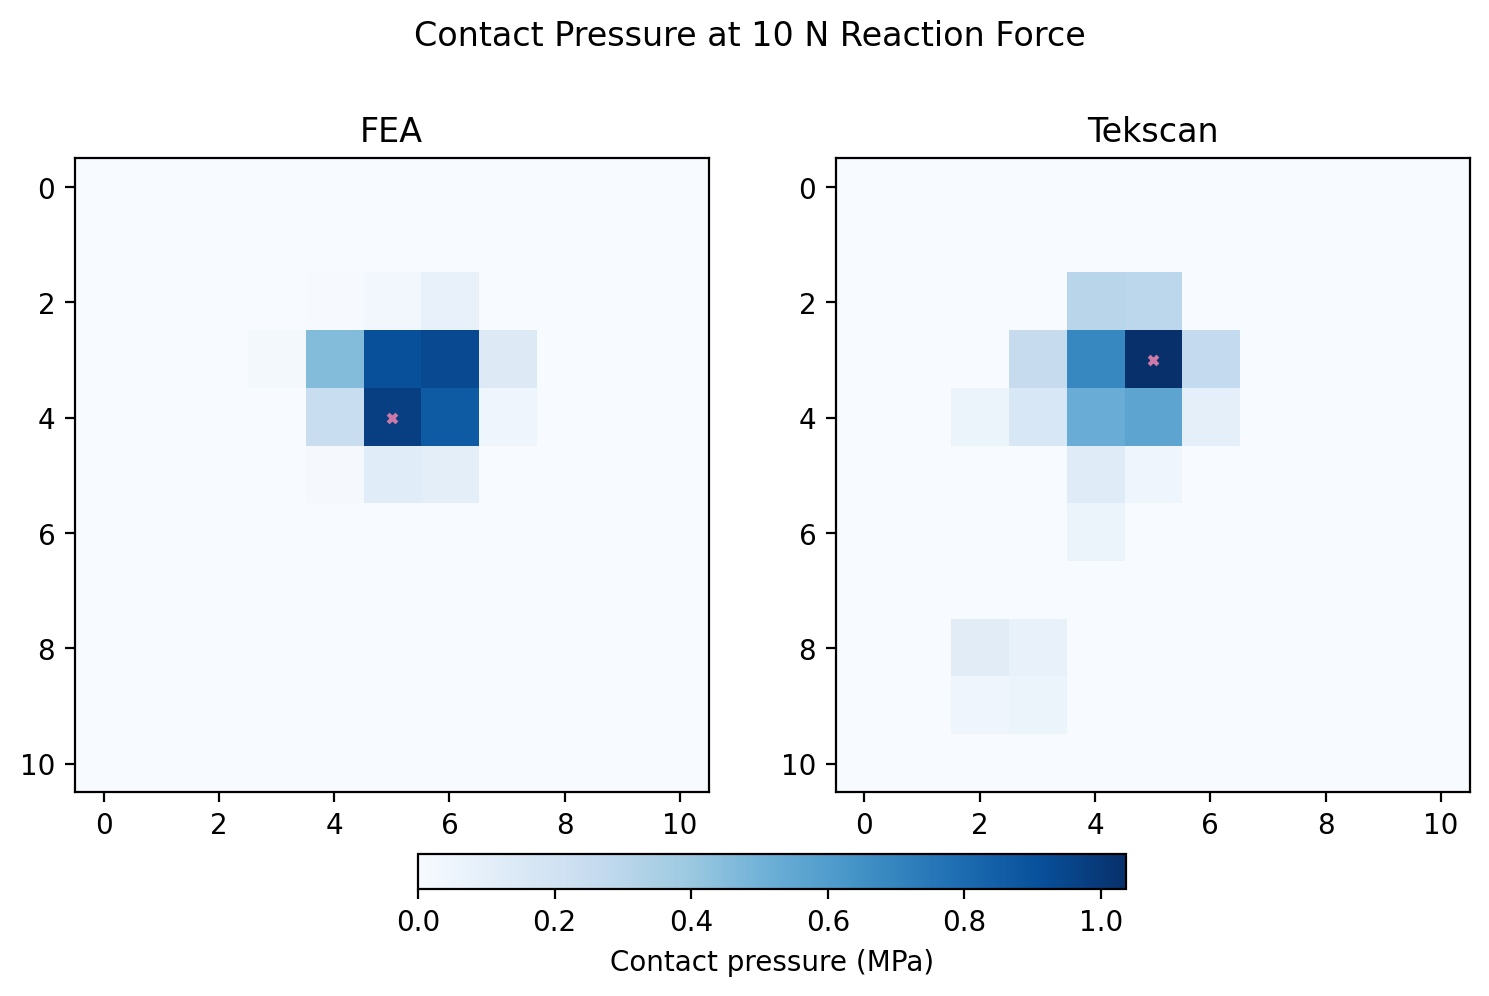

In [9]:
F = 10

nrows, ncols = 1, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 5*nrows), dpi=200)

P_fea, P_tek = fea_grid_data[F][::-1], tek_data[F][::-1]

press_min = np.min( [np.min(P_fea), np.min(P_tek)] )
press_max = np.max( [np.max(P_fea), np.max(P_tek)] )
clims = (press_min, press_max)

# imshows
im = ax[0].imshow(P_fea, vmin=clims[0], vmax=clims[1], cmap="Blues")
ax[1].imshow(P_tek, vmin=clims[0], vmax=clims[1], cmap='Blues')

# peak pressure loc
y, x = compute_img_metrics(P_fea)['loc_Pmax']
ax[0].scatter(x, y, color="#cc79a7", s=10, marker='x')
y, x = compute_img_metrics(P_tek)['loc_Pmax']
ax[1].scatter(x, y, color="#cc79a7", s=10, marker='x')

ax[0].set_title('FEA')
ax[1].set_title('Tekscan')
fig.suptitle(f'Contact Pressure at {F} N Reaction Force')

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.08, orientation='horizontal')
cbar.set_label('Contact pressure (MPa)')

plt.show()